In [ ]:
## Creating the geometry and saving to text file


In [ ]:
import math


def write_rod_txt(
    filename,
    num_nodes,
    spacing=0.01,
    angle_to_vertical_deg=0.0,
    radial_angle_xy_deg=0.0,
):
    """
    Generate a straight rod in 3D.

    Angles:
        angle_to_vertical_deg:
            polar angle from +z axis.
            0 deg  -> along +z
            90 deg -> lies in xy plane

        radial_angle_xy_deg:
            azimuth angle of the rod projection in the xy plane.
            0 deg  -> +x direction
            90 deg -> +y direction

    Coordinates:
        x = r sin(theta) cos(phi)
        y = r sin(theta) sin(phi)
        z = r cos(theta)
    """

    if num_nodes < 2:
        raise ValueError("num_nodes must be at least 2")

    theta = math.radians(angle_to_vertical_deg)
    phi = math.radians(radial_angle_xy_deg)

    dx = spacing * math.sin(theta) * math.cos(phi)
    dy = spacing * math.sin(theta) * math.sin(phi)
    dz = spacing * math.cos(theta)

    filename = filename.format(angle_to_vertical_deg,radial_angle_xy_deg,num_nodes)


    with open(filename, "w") as f:
        f.write("*Nodes\n")

        for i in range(num_nodes):
            x = i * dx
            y = i * dy
            z = i * dz

            f.write(f"{x:g},{y:g},{z:g}\n")

        f.write("*Edges\n")

        for i in range(1, num_nodes):
            f.write(f"{i},{i + 1}\n")

    print("Saved to:",filename)


write_rod_txt(
    filename="../tests/resources/pci/angled{}v_azi{}_rod_n{}.txt",
    num_nodes=11,
    spacing=0.01,
    angle_to_vertical_deg=1,
    radial_angle_xy_deg=90,
)



Saved to: ../tests/resources/pci/angled1v_azi90_rod_n11.txt


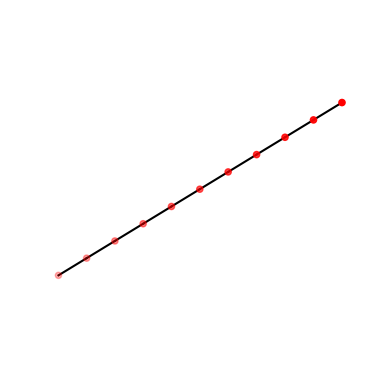

In [183]:
import numpy as np
import dismech

geom = dismech.GeomParams(rod_r0=5e-3,
                          shell_h=0)

material = dismech.Material(density=500,
                            youngs_rod=5e4,
                            youngs_shell=0,
                            poisson_rod=0.5,
                            poisson_shell=0)

dt = 1e-3
dyn_3d_sim = dismech.SimParams(static_sim=False,
                                  two_d_sim=False,
                                  use_mid_edge=False,
                                  use_line_search=False,
                                  show_floor=False,
                                  log_data=True,
                                  log_step=1,
                                  dt=dt,
                                  max_iter=25,
                                  total_time=1.0,
                                  plot_step=1,
                                  tol=1e-4,
                                  ftol=1e-4,
                                  dtol=1e-2)

env = dismech.Environment()
env.add_force('gravity', g=np.array([0.0, 0.0, -9.81]))
# env.add_force('damping', eta=1)

angleV = 1
angleAzi = 90
# geo = dismech.Geometry.from_txt('../tests/resources/rod_cantilever/vertical_rod_n11.txt')
geo = dismech.Geometry.from_txt('../tests/resources/pci/angled{}v_azi{}_rod_n11.txt'.format(angleV, angleAzi))


robot = dismech.SoftRobot(geom, material, geo, dyn_3d_sim, env)

In [157]:
import numpy as np


def stretch_nodes_from_txt(
    input_txt,
    output_csv,
    stretch_factor=1.0,
    direction=(1.0, 0.0, 0.0),
):
    """
    Read *Nodes from a rod .txt file and write stretched node coordinates
    to a headerless CSV compatible with:

        r_ref = np.loadtxt(ref_path, delimiter=",")

    Output shape:
        (N_nodes, 3)
    """

    direction = np.array(direction, dtype=float)
    direction /= np.linalg.norm(direction)

    nodes = []
    reading_nodes = False

    with open(input_txt, "r") as f:
        for line in f:
            line = line.strip()

            if line == "*Nodes":
                reading_nodes = True
                continue

            if line == "*Edges":
                reading_nodes = False
                continue

            if reading_nodes and line:
                nodes.append([float(v) for v in line.split(",")])

    nodes = np.array(nodes, dtype=float)

    # Stretch only the component along the specified direction
    stretched_nodes = []
    for p in nodes:
        p_parallel = np.dot(p, direction) * direction
        p_perp = p - p_parallel
        p_new = p_perp + stretch_factor * p_parallel
        stretched_nodes.append(p_new)

    stretched_nodes = np.array(stretched_nodes)

    np.savetxt(
        output_csv,
        stretched_nodes,
        delimiter=",",
        fmt="%.10g",
    )


# # Example
# stretch_nodes_from_txt(
#     input_txt="rod.txt",
#     output_csv="r_ref_stretched.csv",
#     stretch_factor=1.2,
#     direction=(0, 0, 1),
# )

# Example usage
stretch_nodes_from_txt(
    input_txt="../tests/resources/rod_cantilever/vertical_rod_n11.txt",
    output_csv="../tests/resources/pci/vertical_stretched_n11.csv",
    stretch_factor=1.5,
    direction=(0, 0, 1),  # stretch along z
)

In [ ]:

# Path to your CSV file
ref_path = "../tests/resources/pci/vertical_stretched_n11.csv"

# Read the file (comma-separated, no header)
r_ref = np.loadtxt(ref_path, delimiter=",")

# r_ref: (N_nodes,3)

nodes_ind = robot.stretch_springs.nodes_ind     # (N_edges, 2)
L0        = robot.stretch_springs.ref_len       # (N_edges,)

p0 = r_ref[nodes_ind[:,0]]
p1 = r_ref[nodes_ind[:,1]]
Lref = np.linalg.norm(p1 - p0, axis=1)
eps_ref = Lref / L0 - 1.0  #strains of the new config compared to base

In [187]:
L0

array([0.01      , 0.01000004, 0.00999992, 0.01000002, 0.01000002,
       0.01000002, 0.00999992, 0.01000002, 0.01000002, 0.01000002])

In [186]:
Lref

array([0.015, 0.015, 0.015, 0.015, 0.015, 0.015, 0.015, 0.015, 0.015,
       0.015])

In [136]:
print(eps_ref)

[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]


In [179]:
a = [1, 1, 1 , 1,1,0,0,0,0,0]
eps_ref*a

array([0.49999954, 0.49999354, 0.50001154, 0.49999654, 0.49999654,
       0.        , 0.        , 0.        , 0.        , 0.        ])

In [184]:
from dismech.controllers.longitudinalPI import LongitudinalPI


fixed_points = np.array([0, 1])
robot = robot.fix_nodes(fixed_points)
stepper = dismech.ImplicitEulerTimeStepper(robot)


stiffen_s = 100
stiffen_b = 1000

dtrate = 200

nlenEA =  robot.stretch_springs.EA.size
nlenEI = robot.bend_springs.EI.shape[0]
EA0 = robot.stretch_springs.EA[0]*stiffen_s
EI0 = robot.bend_springs.EI[0]*stiffen_b
EA_spatial = np.zeros(nlenEA)

Kp = 5
Ki = 100
Kd = 1

nat0 = robot.stretch_springs.nat_strain.copy()  # shape (N_edges,)
pid  = LongitudinalPI(eps_ref, nat0, Kp=Kp, Ki=Ki, Kd=Kd,
                        du_rate=0.02, smooth_alpha=0.10)

dt = dyn_3d_sim.dt
stretch_energy = None
pos_errors = []
strain_errors = []


def update_EA(robot: dismech.SoftRobot, t: float):
    tstep =int( t/dt)

    num_active = min((tstep // dtrate) + 1, nlenEA) # Determines the rate of travel of the air bubble. Right now it is travelling a rod length every 100 timesteps. This needs to grounded in the real flow rate and the air bubble travel rate
    current_active = int(np.sum(EA_spatial))

    # Only update if num_active changed
    if num_active > current_active:

        EA_spatial[current_active:num_active] = 1

        EA_added = np.zeros(nlenEA)
        EA_added[current_active:num_active] = 1

        EI_added = np.zeros((nlenEI,1))
        EI_added[current_active:num_active] = 1

        robot.stretch_springs.EA += EA_added * EA0
        robot.bend_springs.EI += EI_added * EI0

    return robot

def before_step_fn(rb, t):
    tstep =int( t/dt)

    num_active = min((tstep // dtrate) + 1, nlenEA) # Determines the rate of travel of the air bubble. Right now it is travelling a rod length every 100 timesteps. This needs to grounded in the real flow rate and the air bubble travel rate
    current_active = int(np.sum(EA_spatial))



    # fetch StretchEnergy from the stepper on every call (cheap)
    se = stepper.elastic_energies['stretch']

    # 1) measure current edge strains from the current state
    eps_meas = se.get_strain(rb.state)  # (N_edges,)

    # Only update if num_active changed
    if num_active > current_active:

        EA_spatial[current_active:num_active] = 1
        print("EA_spatial:", EA_spatial)
        print("Sliced eps_ref",pid.eps_ref*EA_spatial)
        print("eps meas", eps_meas)

    # 2) PI update on natural strain (in-place write)
    pid.update(eps_meas, rb.stretch_springs.nat_strain, dt)

    # print the error between target and measured strain
    err = np.linalg.norm(eps_meas - eps_ref) / np.sqrt(len(eps_meas))
    strain_errors.append(err)
    # print(f"t={t:.3f}, ||eps-eps_ref||={err:.6f}")

    # also print the error between the state and the reference (nodal positions)
    curr_pos = rb.state.q[0:rb.end_node_dof_index] # (N_nodes*3,)
    ref_pos = r_ref.reshape(-1)                   # (N_nodes*3,)
    pos_err = np.linalg.norm(curr_pos - ref_pos) / np.sqrt(len(curr_pos))
    # print(f"t={t:.3f}, ||pos-ref_pos||={pos_err:.6f}")

    # save this pos_err for later plotting
    pos_errors.append(pos_err)

    return rb


# stepper.before_step = update_EA

stepper.before_step = before_step_fn

robots, t_arr, f_norms = stepper.simulate()
qs = np.stack([robot.state.q for robot in robots])
vs = np.stack([robot.state.u for robot in robots])
t_arr = np.array(t_arr)
print("EA_spatial:", EA_spatial)

EA_spatial: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Sliced eps_ref [0.49999954 0.         0.         0.         0.         0.
 0.         0.         0.         0.        ]
eps meas [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
 -1.11022302e-16  0.00000000e+00]
iter: 1, error: 0.078
iter: 2, error: 0.001
current_time:  0.001
iter: 1, error: 0.170
iter: 2, error: 0.000
current_time:  0.002
iter: 1, error: 0.200
iter: 2, error: 0.000
current_time:  0.003
iter: 1, error: 0.272
iter: 2, error: 0.000
current_time:  0.004
iter: 1, error: 0.339
iter: 2, error: 0.000
current_time:  0.005
iter: 1, error: 0.382
iter: 2, error: 0.000
current_time:  0.006
iter: 1, error: 0.387
iter: 2, error: 0.000
current_time:  0.007
iter: 1, error: 0.383
iter: 2, error: 0.000
current_time:  0.008
iter: 1, error: 0.315
iter: 2, error: 0.000
current_time:  0.009000000000000001
iter: 1, error: 0.241
iter: 2, error: 0.000
current_time:  0.01

In [173]:
options = dismech.AnimationOptions(title='Rod (N=11)) Vertical Angle {} Azimuth {}'.format(angleV, angleAzi), plot_step=10)

fig = dismech.get_interactive_animation_plotly(robot, t_arr, qs, options)
fig.show()

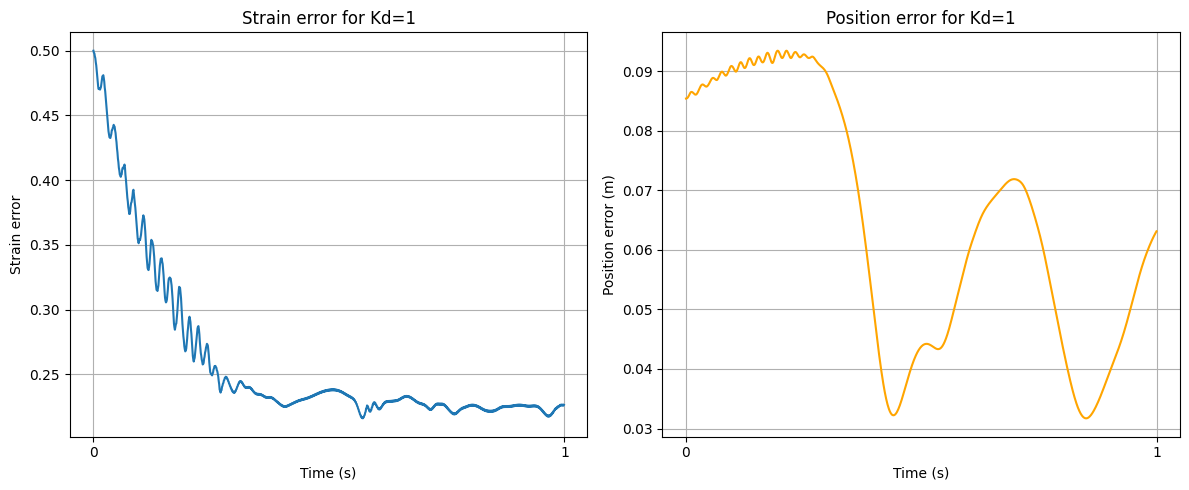

In [174]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
# make the strain error and position error plots side-by-side
t = np.arange(robot.sim_params.total_time, step=robot.sim_params.dt)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(t, strain_errors)
ax1.set_title("Strain error for Kd={Kd}".format(Kd=Kd))
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Strain error")
ax1.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax1.grid(True)
ax2.plot(t, pos_errors, color='orange')
ax2.set_title("Position error for Kd={Kd}".format(Kd=Kd))
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Position error (m)")
ax2.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax2.grid(True)
plt.tight_layout()
plt.show()